In [3]:
# Lectura de archivo y exploración de datos
import pandas as pd

df_soja = pd.read_csv("soja-serie-1941-2023.csv")

print(df_soja.head()) # Primeras 5 filas
print(df_soja.info()) # Muestro información general
print(df_soja.describe()) # Estadísticas descriptivas

  cultivo_nombre  anio   campania provincia_nombre  provincia_id  \
0           soja  1941  1941/1942         Misiones            54   
1           soja  1941  1941/1942         Misiones            54   
2           soja  1941  1941/1942         Misiones            54   
3           soja  1941  1941/1942         Misiones            54   
4           soja  1941  1941/1942         Misiones            54   

  departamento_nombre  departamento_id  superficie_sembrada_ha  \
0            Cainguás            54014                     300   
1          Candelaria            54021                     100   
2              Iguazú            54063                      70   
3         San Ignacio            54098                     100   
4          San Javier            54105                      30   

   superficie_cosechada_ha  produccion_tm  rendimiento_kgxha  
0                      200            140                700  
1                      100            100               1000  
2    

In [5]:
# Verifico valores faltantes
print(df_soja.isnull().sum())

cultivo_nombre             0
anio                       0
campania                   0
provincia_nombre           0
provincia_id               0
departamento_nombre        0
departamento_id            0
superficie_sembrada_ha     0
superficie_cosechada_ha    0
produccion_tm              0
rendimiento_kgxha          0
dtype: int64


In [7]:
# Verifico valores duplicados
print("Duplicados:", df_soja.duplicated().sum())

Duplicados: 0


In [9]:
# Muestro tipos de datos
print(df_soja.dtypes)

cultivo_nombre             object
anio                        int64
campania                   object
provincia_nombre           object
provincia_id                int64
departamento_nombre        object
departamento_id             int64
superficie_sembrada_ha      int64
superficie_cosechada_ha     int64
produccion_tm               int64
rendimiento_kgxha           int64
dtype: object


In [11]:
# Busco si hay valores negativos
print((df_soja["superficie_sembrada_ha"] < 0).sum())
print((df_soja["superficie_cosechada_ha"] < 0).sum())
print((df_soja["produccion_tm"] < 0).sum())
print((df_soja["rendimiento_kgxha"] < 0).sum())

0
0
0
0


In [13]:
# Filtro para obtener los datos desde 1981 en adelante
df_soja = df_soja[df_soja["anio"] >= 1981]

In [15]:
# Agrupo datos por provincia y año
df_provincia = df_soja.groupby(
    ["provincia_nombre", "anio"],
    as_index=False
).agg({
    "superficie_sembrada_ha": "sum",
    "superficie_cosechada_ha": "sum",
    "produccion_tm": "sum"
})

El dataset original se encuentra a nivel departamental, mientras que las variables climáticas disponibles fueron recopiladas a nivel provincial.

Para mantener coherencia espacial entre ambos conjuntos de datos, se realizó una agregación de la información agrícola agrupando los registros por:

Provincia
Año

Durante este proceso se calcularon los totales provinciales de:
Superficie sembrada.
Superficie cosechada.
Producción total.

De esta forma se obtuvo una única observación por provincia y año.

In [18]:
# Recalculo rendimiento
df_provincia["rendimiento_kgxha"] = (
    df_provincia["produccion_tm"] * 1000
) / df_provincia["superficie_cosechada_ha"]

Luego de la agregación provincial, fue necesario recalcular el rendimiento debido a que el valor original correspondía a cada departamento individual.
El nuevo rendimiento provincial se calculó utilizando la siguiente relación:

Rendimiento (kg/ha) = Producción total (kg) / Superficie cosechada total (ha)

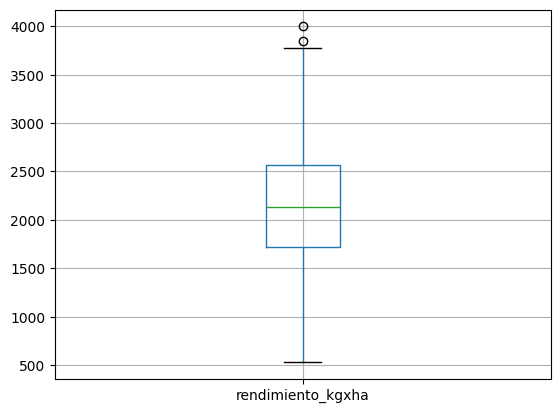

In [21]:
# Grafico outliers
import matplotlib.pyplot as plt

df_provincia.boxplot(column="rendimiento_kgxha")
plt.show()

El boxplot del rendimiento muestra una distribución relativamente equilibrada.

Se observa que:

La mediana del rendimiento se ubica aproximadamente en 2100 kg/ha.
El 50% central de los datos se encuentra entre aproximadamente 1700 y 2600 kg/ha.
Existen algunos valores atípicos superiores cercanos a los 4000 kg/ha.
También se observan rendimientos mínimos cercanos a 500 kg/ha.

Estos valores pueden explicarse por diferencias climáticas, tecnológicas y productivas entre provincias y campañas agrícolas, por lo que no fueron considerados errores y se decidió conservarlos.

In [23]:
# Verifico resultado de lo aplicado
print(df_provincia.head())

  provincia_nombre  anio  superficie_sembrada_ha  superficie_cosechada_ha  \
0     Buenos Aires  1981                  462300                   460900   
1     Buenos Aires  1982                  650000                   648100   
2     Buenos Aires  1983                  715000                   713000   
3     Buenos Aires  1984                  830000                   825000   
4     Buenos Aires  1985                  851500                   849350   

   produccion_tm  rendimiento_kgxha  
0         924500        2005.858104  
1         950000        1465.823175  
2        1670000        2342.215989  
3        1600000        1939.393939  
4        1988000        2340.613410  


In [26]:
# Para hacer el segundo dataset, verifico que provincias son las registradas
provincias = sorted(df_provincia["provincia_nombre"].unique())

print("Cantidad de provincias:", len(provincias))
print(provincias)

Cantidad de provincias: 15
['Buenos Aires', 'Catamarca', 'Chaco', 'Corrientes', 'Córdoba', 'Entre Ríos', 'Formosa', 'Jujuy', 'La Pampa', 'Misiones', 'Salta', 'San Luis', 'Santa Fe', 'Santiago del Estero', 'Tucumán']


In [28]:
df_provincia.to_csv("soja_provincia_1981_2023.csv", index=False)

In [30]:
# Dataset climático (Excel)
df_clima = pd.read_excel("registro_climatico_por_provincia_1981_2023.xlsx")

In [36]:
print(df_provincia['provincia_nombre'].unique())
print(df_clima['provincia'].unique())

['Buenos Aires' 'Catamarca' 'Chaco' 'Corrientes' 'Córdoba' 'Entre Ríos'
 'Formosa' 'Jujuy' 'La Pampa' 'Misiones' 'Salta' 'San Luis' 'Santa Fe'
 'Santiago del Estero' 'Tucumán']
['Buenos Aires' 'Catamarca' 'Chaco' 'Corrientes' 'Córdoba' 'Entre Ríos'
 'Formosa' 'Jujuy' 'La Pampa' 'Misiones' 'Salta' 'San Luis' 'Santa Fe'
 'Santiago del Estero' 'Tucumán']


In [38]:
df_final = pd.merge(
    df_provincia,
    df_clima,
    left_on=['provincia_nombre', 'anio'],
    right_on=['provincia', 'anio'],
    how='inner'
)

df_final.drop(columns=['provincia'], inplace=True)

In [40]:
print(df_provincia.shape)
print(df_clima.shape)
print(df_final.shape)

(630, 6)
(645, 5)
(630, 9)


In [44]:
df_final.head()

,provincia_nombre,anio,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha,precipitacion_total,temperatura_media,humedad_relativa
0,Buenos Aires,1981,462300,460900,924500,2005.858104,805.88,15.35,71.83
1,Buenos Aires,1982,650000,648100,950000,1465.823175,844.86,15.28,71.62
2,Buenos Aires,1983,715000,713000,1670000,2342.215989,908.29,14.75,73.22
3,Buenos Aires,1984,830000,825000,1600000,1939.393939,924.56,14.33,75.99
4,Buenos Aires,1985,851500,849350,1988000,2340.613410,809.75,15.42,70.21


In [46]:
df_final.to_csv('soja_clima_1981_2023.csv', index=False)